In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.metrics import (roc_auc_score, f1_score, classification_report,
                             ConfusionMatrixDisplay, make_scorer)
import xgboost as xgb
import lightgbm as lgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

OUTPUT_DIR = Path("../outputs")
MODEL_DIR  = Path("../models")
MODEL_DIR.mkdir(exist_ok=True)

d:\projects\CoughDetector\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
X = np.load('../data/X_cv.npy')
y = np.load('../data/y_cv.npy')
feature_names = joblib.load('../data/feature_names.pkl')

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"COVID-19 %: {y.mean():.1%}")

X shape: (16213, 190)
y shape: (16213,)
COVID-19 %: 7.9%


In [4]:
X_train, X_holdout, y_train, y_holdout = train_test_split(
    X, y,
    test_size=0.15,
    random_state=42,
    stratify=y
)

print(f"Training set:  {X_train.shape} | COVID %: {y_train.mean():.1%}")
print(f"Holdout set:   {X_holdout.shape} | COVID %: {y_holdout.mean():.1%}")

# Save holdout immediately — don't touch it until final evaluation
np.save('../data/X_holdout.npy', X_holdout)
np.save('../data/y_holdout.npy', y_holdout)
print("\nHoldout saved — not touching until final evaluation.")

Training set:  (13781, 190) | COVID %: 7.9%
Holdout set:   (2432, 190) | COVID %: 7.9%

Holdout saved — not touching until final evaluation.


In [5]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale = neg / pos  # for XGBoost

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'auroc': make_scorer(roc_auc_score, needs_proba=True),
    'f1':    make_scorer(f1_score, average='macro')
}

models = {
    'LogReg': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(class_weight='balanced',
                                   max_iter=1000, random_state=42))
    ]),
    'RandomForest': RandomForestClassifier(
        n_estimators=300, class_weight='balanced',
        n_jobs=-1, random_state=42
    ),
    'XGBoost': xgb.XGBClassifier(
        scale_pos_weight=scale, n_estimators=300,
        eval_metric='logloss', random_state=42
    ),
    'LightGBM': lgb.LGBMClassifier(
        class_weight='balanced', n_estimators=300,
        random_state=42, verbose=-1
    ),
    'SVM': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(kernel='rbf', probability=True,
                    class_weight='balanced', random_state=42))
    ])
}

print(f"neg/pos ratio (scale_pos_weight): {scale:.1f}")

neg/pos ratio (scale_pos_weight): 11.7


d:\projects\CoughDetector\.venv\Lib\site-packages\sklearn\metrics\_scorer.py:610: FutureWarning: The `needs_threshold` and `needs_proba` parameter are deprecated in version 1.4 and will be removed in 1.6. You can either let `response_method` be `None` or set it to `predict` to preserve the same behaviour.
  warnings.warn(


In [6]:
results = {}

for name, model in models.items():
    print(f"Training {name}...", end=' ')
    scores = cross_validate(model, X_train, y_train,
                            cv=cv, scoring=scoring,
                            return_train_score=False, n_jobs=-1)
    results[name] = {
        'auroc_mean': scores['test_auroc'].mean(),
        'auroc_std':  scores['test_auroc'].std(),
        'f1_mean':    scores['test_f1'].mean(),
        'f1_std':     scores['test_f1'].std(),
    }
    print(f"AUROC: {results[name]['auroc_mean']:.4f} ± {results[name]['auroc_std']:.4f}")

results_df = pd.DataFrame(results).T.sort_values('auroc_mean', ascending=False)
print("\n", results_df.round(4))

Training LogReg... AUROC: 0.6021 ± 0.0166
Training RandomForest... AUROC: 0.6012 ± 0.0104
Training XGBoost... AUROC: 0.5817 ± 0.0261
Training LightGBM... AUROC: 0.5767 ± 0.0134
Training SVM... AUROC: 0.6058 ± 0.0153

               auroc_mean  auroc_std  f1_mean  f1_std
SVM               0.6058     0.0153   0.5248  0.0069
LogReg            0.6021     0.0166   0.4570  0.0075
RandomForest      0.6012     0.0104   0.4795  0.0001
XGBoost           0.5817     0.0261   0.4853  0.0036
LightGBM          0.5767     0.0134   0.4824  0.0045


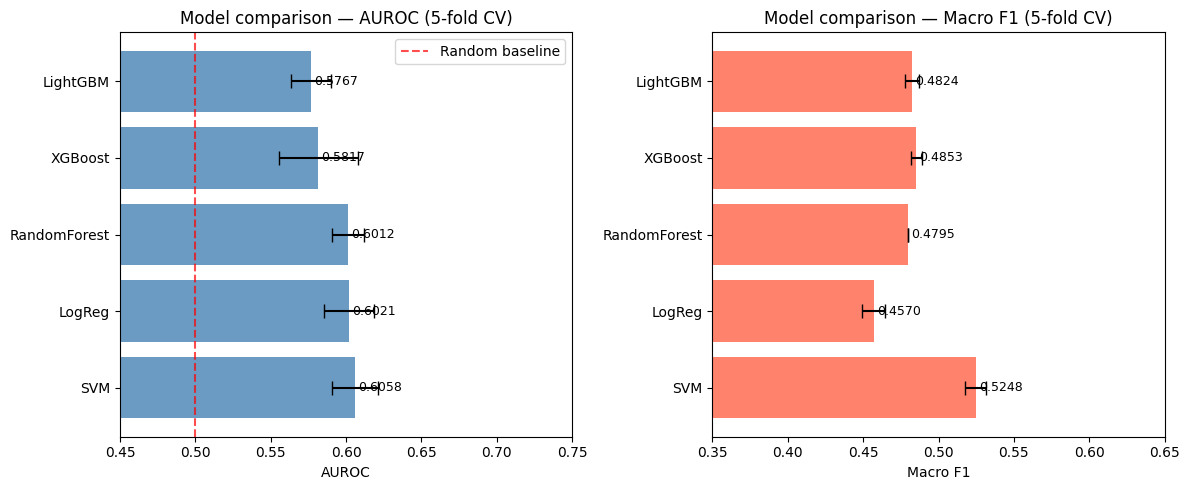

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

models_list = results_df.index.tolist()
auroc_means = results_df['auroc_mean'].values
auroc_stds  = results_df['auroc_std'].values
f1_means    = results_df['f1_mean'].values
f1_stds     = results_df['f1_std'].values

# AUROC
bars = axes[0].barh(models_list, auroc_means, xerr=auroc_stds,
                     color='steelblue', alpha=0.8, capsize=5)
axes[0].axvline(x=0.5, color='red', linestyle='--', alpha=0.7, label='Random baseline')
axes[0].set_xlabel('AUROC')
axes[0].set_title('Model comparison — AUROC (5-fold CV)')
axes[0].set_xlim(0.45, 0.75)
axes[0].legend()
for bar, val in zip(bars, auroc_means):
    axes[0].text(val + 0.002, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=9)

# F1
bars2 = axes[1].barh(models_list, f1_means, xerr=f1_stds,
                      color='tomato', alpha=0.8, capsize=5)
axes[1].set_xlabel('Macro F1')
axes[1].set_title('Model comparison — Macro F1 (5-fold CV)')
axes[1].set_xlim(0.35, 0.65)
for bar, val in zip(bars2, f1_means):
    axes[1].text(val + 0.002, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
def objective_lgbm(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 800),
        'num_leaves':        trial.suggest_int('num_leaves', 20, 150),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'class_weight':      'balanced',
        'random_state':      42,
        'verbose':           -1,
    }
    model = lgb.LGBMClassifier(**params)
    scores = cross_validate(model, X_train, y_train,
                            cv=cv,
                            scoring={'auroc': make_scorer(roc_auc_score,
                                     response_method='predict_proba')},
                            return_train_score=False)
    return scores['test_auroc'].mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective_lgbm, n_trials=50, show_progress_bar=True)

print(f"\nBest AUROC: {study.best_value:.4f}")
print(f"Best params: {study.best_params}")

  0%|          | 0/30 [00:00<?, ?it/s]d:\projects\CoughDetector\.venv\Lib\site-packages\sklearn\metrics\_scorer.py:610: FutureWarning: The `needs_threshold` and `needs_proba` parameter are deprecated in version 1.4 and will be removed in 1.6. You can either let `response_method` be `None` or set it to `predict` to preserve the same behaviour.
  warnings.warn(
Best trial: 0. Best value: 0.494428:   3%|▎         | 1/30 [04:20<2:05:57, 260.59s/it]d:\projects\CoughDetector\.venv\Lib\site-packages\sklearn\metrics\_scorer.py:610: FutureWarning: The `needs_threshold` and `needs_proba` parameter are deprecated in version 1.4 and will be removed in 1.6. You can either let `response_method` be `None` or set it to `predict` to preserve the same behaviour.
  warnings.warn(
Best trial: 1. Best value: 0.505372:   7%|▋         | 2/30 [10:18<2:28:13, 317.63s/it]d:\projects\CoughDetector\.venv\Lib\site-packages\sklearn\metrics\_scorer.py:610: FutureWarning: The `needs_threshold` and `needs_proba` param

[W 2026-07-07 13:13:19,894] Trial 3 failed with parameters: {'C': 3.863284984864648, 'gamma': 'scale', 'kernel': 'poly'} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "d:\projects\CoughDetector\.venv\Lib\site-packages\optuna\study\_optimize.py", line 197, in _run_trial
    value_or_values = func(trial)
  File "C:\Users\jovis\AppData\Local\Temp\ipykernel_33456\4140745831.py", line 16, in objective_svm
    scores = cross_validate(model, X_train, y_train,
                            cv=cv, scoring={'auroc': make_scorer(roc_auc_score, needs_proba=True)},
                            return_train_score=False)
  File "d:\projects\CoughDetector\.venv\Lib\site-packages\sklearn\utils\_param_validation.py", line 213, in wrapper
    return func(*args, **kwargs)
  File "d:\projects\CoughDetector\.venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 423, in cross_validate
    results = parallel(
        delayed(_fit_and_score)(
    ...

KeyboardInterrupt: 